# Description
We aim to compare the process of creating a PD model using a logistic regression and a common ML method (LGBM - Ligh Gradient Boosting Machine)
<br>This notebook aims to compare the models performance accross different segments

# Setup

In [38]:
import pandas as pd
import numpy as np
import plotly.express as px
from IPython.display import Image
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import tree
import statsmodels.api as sm
import joblib
import lightgbm as lgbm
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score
from string import ascii_lowercase as abc
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt
import shap

# Data

In [39]:
project_folder = "02_base_pipeline"

input_path = f"..\\..\\data\\inputs\\{project_folder}\\"
output_path = f"..\\..\\data\\outputs\\{project_folder}\\"

In [40]:
train_df = pd.read_parquet(f'{output_path}train_df.parquet')
test_df =  pd.read_parquet(f'{output_path}test_df.parquet')

In [41]:
train_df.columns.to_list()

['loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'loan_status',
 'pymnt_plan',
 'purpose',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_amnt',
 'last_fico_range_high',
 'last_fico_range_low',
 'policy_code',
 'application_type',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_bal',
 'total_rev_hi_lim',
 'acc_open_past_24mths',
 'avg_cur_bal',
 'bc_open_to_buy',
 'bc_util',
 'chargeoff_within_12_mths',
 'delinq_amnt',
 'mo_sin_old_il_acct',
 'mo_sin_old_rev_tl_op',
 'mo_sin_rcnt_rev_tl_op',
 'mo_sin_rcnt_tl',
 'mort_acc',
 'mths_si

## Models

In [42]:
class logRegWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, log_reg):
        self.log_reg = log_reg
        self.feature_name_ = log_reg.params.index
        self.feature_names_in_ = log_reg.params.index
        self.classes_ = np.array([0,1], dtype=int)
        self.params = log_reg.params.to_dict()
        self.intercept_ = np.array(0, dtype=float)
        self.coef_ = list(self.params.values())
        self.coef_ = np.array(self.coef_, dtype=float)
    
    def fit(self, x, y):
        pass
        
    def predict_proba(self, data):
        pred_series = self.log_reg.predict(data)
        pred_series_2 = 1 - pred_series
        return np.column_stack((pred_series_2 , pred_series))
    
    def predict(self, data):
        pred_series = self.log_reg.predict(data)
        pred_series_2 = 1 - pred_series
        return np.column_stack((pred_series_2 , pred_series))
    
    def __sklearn_tags__(self):
        tags = super().__sklearn_tags__()
        tags.estimator_type = "classifier"
        return tags
    
models = {
    'log_reg' : logRegWrapper(joblib.load(f'{output_path}log_reg_out.gz')),
    'log_reg_opt' :           joblib.load(f'{output_path}log_reg_opt.gz'),
    'lgbm_model_opt' :        joblib.load(f'{output_path}lgbm_model_opt.gz'),
}

# Analysis

In [43]:
bands_thresholds = {
    'loan_amnt' : [float("-inf"), 600, float("+inf")],
    # 'external_score' : [float("-inf"), 200, 500, 800, float("+inf")],
    # 'days_late' : [float("-inf"), 5, 15, 30, 60, float("+inf")],
}

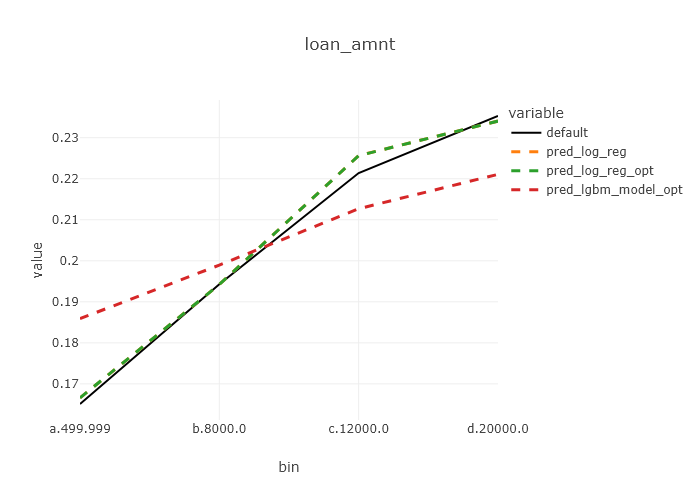

In [44]:
def objectToCategory(df: pd.DataFrame):
    cols_dict = df.dtypes.to_dict()
    change_type_dict = {}
    for col_i, type_i in cols_dict.items():
        if type_i == "object":
            change_type_dict[col_i] = "category"
    result = df.astype(change_type_dict)
    return result

def withModelPred(df: pd.DataFrame, model, suffix: str):
    result = df.copy()
    result = sm.add_constant(result, has_constant='add')
    result[f'pred_{suffix}'] = model.predict_proba(result[model.feature_names_in_])[:,1]
    return result

def withAllModelPreds(df: pd.DataFrame, models: dict):
    result = df.copy()
    for name_i, model_i in models.items():
        result = result.pipe(withModelPred, model_i, name_i)
    return result

def withAggregatedResults(df: pd.DataFrame, group_cols: list, n_cuts: int):
    agg_cols = [i for i in df.columns if 'pred_' in i]
    agg_cols.append('default')
    result = df.copy()
    abc_list = list(abc)
    for col_i in group_cols:
        if result[col_i].dtype in ['float', 'int']:
            result[f'{col_i}_bands'] = pd.arrays.IntervalArray(pd.qcut(result[col_i], n_cuts)).left
        else:
            result[f'{col_i}_bands'] = result[f'{col_i}']
        map_dict = {}
        for i, band_i in enumerate(result[f'{col_i}_bands'].sort_values().unique()):
            map_dict[band_i] = abc_list[i] + '.' + str(band_i)
        result[f'{col_i}_bands'] = result[f'{col_i}_bands'].map(map_dict)
    result['bin'] = result[[f'{col_i}_bands' for col_i in group_cols]].astype('str').T.agg('_'.join)
    result = result\
                .groupby(['bin'])\
                [agg_cols]\
                .agg('mean')\
                .reset_index()
    return result

def withAggregatedResults2(df: pd.DataFrame, group_cols: list, threshold_cuts: dict):
    agg_cols = [i for i in df.columns if 'pred_' in i]
    agg_cols.append('default')
    result = df.copy()
    abc_list = list(abc)
    bands_cols = [f'{col_i}_bands' for col_i in group_cols]
    for col_i in group_cols:
        result[f'{col_i}_bands'] = pd.arrays.IntervalArray(pd.cut(result[col_i], threshold_cuts[col_i])).left
        map_dict = {}
        for i, band_i in enumerate(result[f'{col_i}_bands'].sort_values().unique()):
            map_dict[band_i] = abc_list[i] + '.' + str(band_i)
        result[f'{col_i}_bands'] = result[f'{col_i}_bands'].map(map_dict)
    result['bin'] = result[bands_cols].astype('str').T.agg('_'.join)
    result = result\
                .groupby(['bin'] + bands_cols)\
                [agg_cols]\
                .agg('mean')\
                .reset_index()
    return result

def filterDefaultedAccounts(df: pd.DataFrame, threshold: int):
    result = df[df['days_late']<threshold]
    return result

group_cols = ['loan_amnt']

result = test_df\
.rename({'default_flag':'default'}, axis='columns')\
.pipe(objectToCategory)\
.pipe(withAllModelPreds, models)\
.pipe(withAggregatedResults, group_cols, 4)



fig = px.line(result,
              title = group_cols[0],
              x='bin',
              y=['default'] + [f'pred_{i}' for i in models],
              template='none',
              width=700
        )
fig.update_traces(patch={'line':{'dash':'dash', 'width':3}})
fig.update_traces(patch={'line':{'dash':'solid', 'color':'black', 'width':2}}, selector={'name':'default'})
# fig.update_yaxes(range=[0, 0.1])
# fig
Image(fig.to_image('png'))

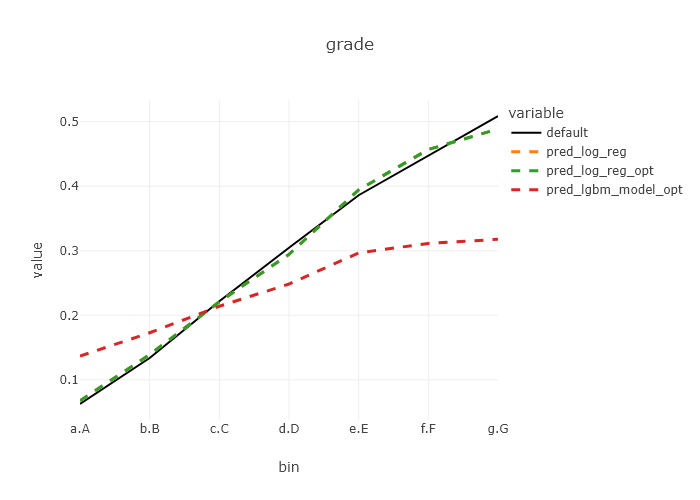

In [45]:
group_cols = ['grade']
result = test_df\
.rename({'default_flag':'default'}, axis='columns')\
.pipe(objectToCategory)\
.pipe(withAllModelPreds, models)\
.pipe(withAggregatedResults, group_cols, 5)

fig = px.line(result,
              title = group_cols[0],
              x='bin',
              y=['default'] + [f'pred_{i}' for i in models],
              template='none',
              width=700
        )
fig.update_traces(patch={'line':{'dash':'dash', 'width':3}})
fig.update_traces(patch={'line':{'dash':'solid', 'color':'black', 'width':2}}, selector={'name':'default'})
# fig
Image(fig.to_image('png'))

## Gini

In [46]:
def aucFromDf(df: pd.DataFrame, pred_col: str, target_col: str, weights: str = None):
    '''
    Calculate auc from pandas dataframe
    '''
    pred = df[pred_col]
    target = df[target_col]
    if weights is None:
      return roc_auc_score(target, pred, sample_weight = weights)
    else:
      return roc_auc_score(target, pred, sample_weight = df[weights])

#Calculate gini from pandas dataframe
def giniFromDf(df: pd.DataFrame, pred_col: str, target_col: str, weights: str = None):
  auc = aucFromDf(df, pred_col, target_col, weights)
  result = (auc - 0.5) * 2
  return result

#Calculate auc by groups from pandas dataframe
def aucPerGroups(df: pd.DataFrame, group_list: list, pred_col: str, target_col: str, weights: str = None):
  result = pd.DataFrame(df.groupby(group_list).apply(aucFromDf, pred_col, target_col, weights), columns=['auc']).reset_index()
  return result

#Calculate gini by groups from pandas dataframe
def giniPerGroups(df: pd.DataFrame, group_list: list, pred_col: str, target_col: str, weights: str = None):
  result = pd.DataFrame(df.groupby(group_list).apply(giniFromDf, pred_col, target_col, weights), columns=['gini']).reset_index()
  return result

In [47]:
train_df\
.pipe(objectToCategory)\
.rename({'default_flag':'default'}, axis='columns')\
.pipe(withAllModelPreds, models)\
.melt(id_vars=['default'], value_vars=[f'pred_{i}' for i in models])\
.pipe(giniPerGroups, ['variable'], 'value', 'default')

C:\Users\GL838PA\AppData\Local\Temp\ipykernel_36860\1970288001.py:25: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,variable,gini
0,pred_lgbm_model_opt,0.413461
1,pred_log_reg,0.416131
2,pred_log_reg_opt,0.416131


In [48]:
test_df\
.pipe(objectToCategory)\
.rename({'default_flag':'default'}, axis='columns')\
.pipe(withAllModelPreds, models)\
.melt(id_vars=['default'], value_vars=[f'pred_{i}' for i in models])\
.pipe(giniPerGroups, ['variable'], 'value', 'default')

C:\Users\GL838PA\AppData\Local\Temp\ipykernel_36860\1970288001.py:25: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,variable,gini
0,pred_lgbm_model_opt,0.412842
1,pred_log_reg,0.415451
2,pred_log_reg_opt,0.415452


## SHAP

In [49]:
class applyShap:
    def __init__(self, model, data):
        self.model = model
        self.data = sm.add_constant(data, has_constant='add')
        self.data = self.data[model.feature_names_in_].pipe(objectToCategory)
    
    def explain(self):
        try:
            self.explainer = shap.TreeExplainer(self.model, feature_perturbation="tree_path_dependent")
        except:
            self.explainer = shap.LinearExplainer(self.model, self.data, feature_names = self.model.feature_names_in_)
        self.shap_values = self.explainer(self.data)
    
    def calculate_shap_values(self):
        self.shap_values = self.explainer(self.data)
    
    def beeswarm_plot(self, max_display=20, log_scale=False):
        try:
            shap.plots.beeswarm(self.shap_values, max_display = max_display, log_scale=log_scale)
        except:
            shap.plots.beeswarm(self.shap_values[:,:,1], max_display = max_display, log_scale=log_scale)
    
    def partial_dependence_plot(self, col_names: list):
        fig, ax = plt.subplots(figsize=(14, 2.5))
        if len(col_names) <=1:
            col_list = col_names
        else:
            col_list = [col_names[0], col_names[1], (col_names[0], col_names[1])]
        PartialDependenceDisplay.from_estimator(self.model, 
                                                self.data, 
                                                col_list,
                                                ax=ax)

In [50]:
models['log_reg'].dummy_ = None
log_reg_shap = applyShap(models['log_reg'], test_df.sample(frac=0.1, random_state=42))
log_reg_shap.explain()

In [51]:
lgbm_shap = applyShap(models['lgbm_model_opt'], test_df.sample(frac=0.01, random_state=42))
lgbm_shap.explain()

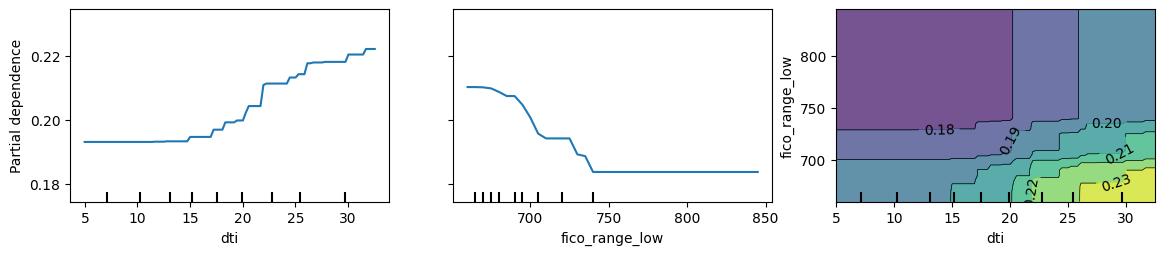

In [52]:
lgbm_shap.partial_dependence_plot(['dti','fico_range_low'])

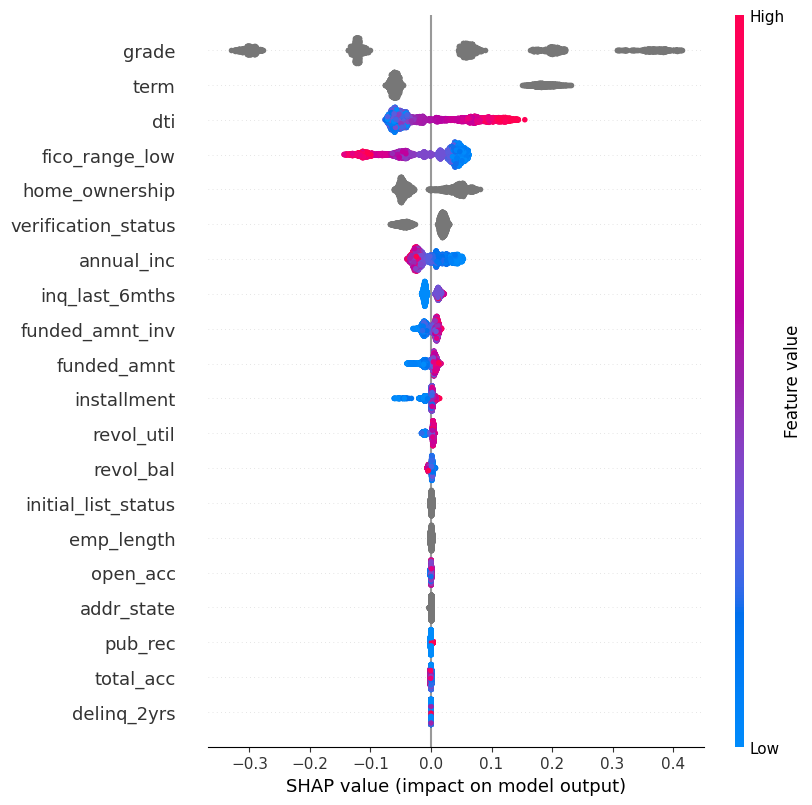

In [53]:
lgbm_shap.beeswarm_plot()

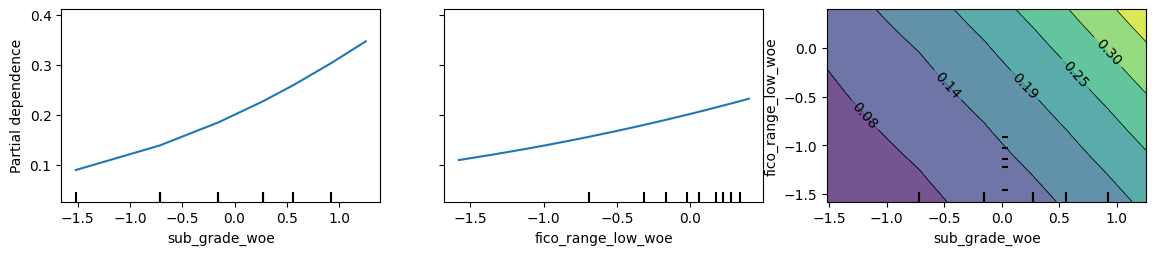

In [54]:
log_reg_shap.partial_dependence_plot(['sub_grade_woe', 'fico_range_low_woe'])

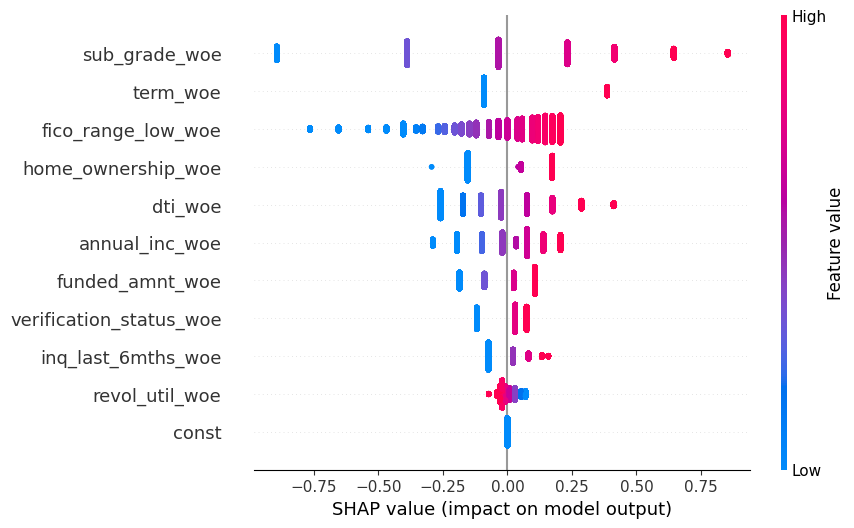

In [22]:
log_reg_shap.beeswarm_plot(max_display=30)

In [24]:
log_reg_opt_shap = applyShap(models['log_reg_opt'], test_df.sample(frac=0.1, random_state=42))
log_reg_opt_shap.explain()

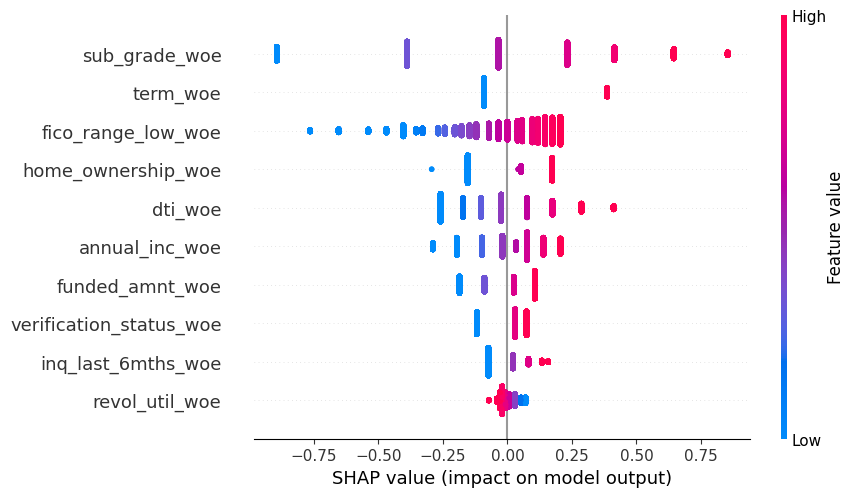

In [25]:
log_reg_opt_shap.beeswarm_plot(max_display=30)

## Scores distribution

In [55]:
def logit_(x):
    return np.log(x/(1-x))

def withScoreFromProb(df: pd.DataFrame, prob_col: str):
    result = df.copy()
    result[f'{prob_col}_score'] = np.round(500 - 20/np.log(2) * logit_(result[f'pred_{prob_col}']),0)
    return result

def withScoreAllModels(df: pd.DataFrame, models: dict):
    result = df.copy()
    for name_i in models.keys():
        result = result.pipe(withScoreFromProb, name_i)
    return result

def withPercentiles(df: pd.DataFrame, col_name: str, n_groups: int):
    df[f'{col_name}_pbins'] = pd.qcut(df[col_name], n_groups, labels=False, duplicates='drop')
    return df

def withGroups(df: pd.DataFrame, col_name: str, n_groups: int):
    grouper = 1000/n_groups
    df[f'{col_name}_bins'] = (df[col_name] /grouper).astype('int') *grouper
    return df

def withAllModelsScoresGrouped(df: pd.DataFrame, models:dict, n_groups: int):
    result = df.copy()
    for name_i in models.keys():
        result = result.pipe(withGroups, f'{name_i}_score', n_groups)
    return result

def withAllModelsPercentiles(df: pd.DataFrame, models:dict, n_groups: int):
    result = df.copy()
    for name_i in models.keys():
        result = result.pipe(withPercentiles, f'{name_i}_score', n_groups)
    return result

scores_df = test_df\
.rename({'default_flag':'default'}, axis='columns')\
.pipe(objectToCategory)\
.pipe(withAllModelPreds, models)\
.pipe(withScoreAllModels, models)\
.pipe(withAllModelsScoresGrouped, models, 75)\
.pipe(withAllModelsPercentiles, models, 10)

scores_df.head()

,const,const,const,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,pred_lgbm_model_opt,log_reg_score,log_reg_opt_score,lgbm_model_opt_score,log_reg_score_bins,log_reg_opt_score_bins,lgbm_model_opt_score_bins,log_reg_score_pbins,log_reg_opt_score_pbins,lgbm_model_opt_score_pbins
0,1.0,1.0,1.0,20000.0,20000.0,20000.0,60 months,0.1699,496.95,D,...,0.342736,493.0,493.0,519.0,480.000000,480.000000,506.666667,0,0,0
1,1.0,1.0,1.0,3000.0,3000.0,3000.0,36 months,0.1114,98.42,B,...,0.151756,568.0,568.0,550.0,560.000000,560.000000,546.666667,8,8,8
2,1.0,1.0,1.0,12000.0,12000.0,12000.0,36 months,0.1099,392.81,B,...,0.163413,560.0,560.0,547.0,560.000000,560.000000,546.666667,7,7,7
3,1.0,1.0,1.0,10000.0,10000.0,10000.0,36 months,0.0789,312.86,A,...,0.123101,586.0,586.0,557.0,573.333333,573.333333,546.666667,9,9,9
4,1.0,1.0,1.0,2400.0,2400.0,2400.0,36 months,0.0819,75.42,A,...,0.145021,557.0,557.0,551.0,546.666667,546.666667,546.666667,6,6,8


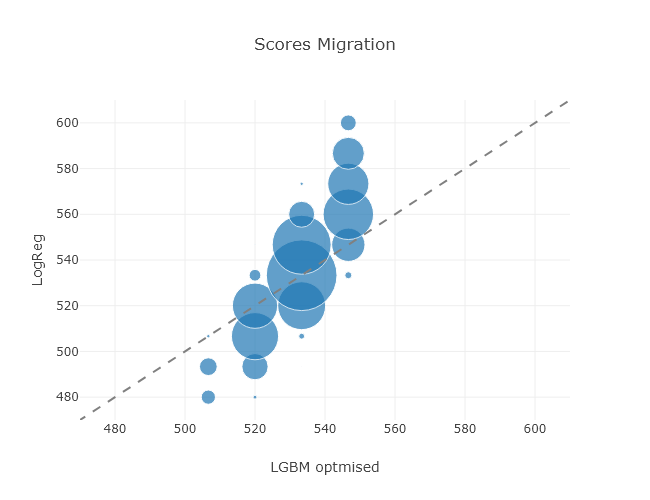

In [63]:
data_chart = scores_df\
.groupby(['lgbm_model_opt_score_bins', 'log_reg_score_bins'])\
[['grade']]\
.agg('count')\
.reset_index()\
.rename({'grade':'count'}, axis='columns')

fig = px.scatter(data_chart, 
                   x='lgbm_model_opt_score_bins',
                   y='log_reg_score_bins',
                   title='Scores Migration',
                   labels={'lgbm_model_opt_score_bins':'LGBM optmised', 'log_reg_score_bins':'LogReg'},
                   size='count',
                   size_max=50,
                   width=650,
                   template='none')
fig.add_shape(type='line',
              x0=0,y0=0,
              x1=800, y1=800,
              line={'color':'grey',
                    'width':2,
                    'dash':'dash'})
fig.update_yaxes(range=[470,610])
fig.update_xaxes(range=[470,610])
Image(fig.to_image('png'))

## Lift charts

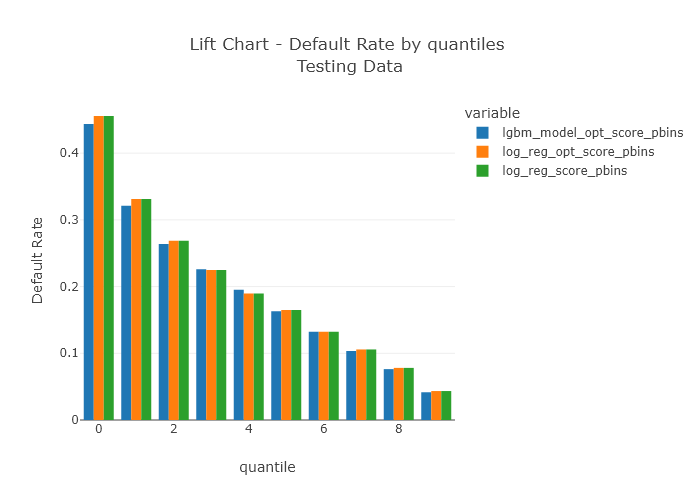

In [64]:
data_chart = scores_df\
.melt(id_vars=['default'], value_vars=[f'{name_i}_score_pbins' for name_i in models.keys()])\
.groupby(['variable','value'])\
.agg('mean')\
.reset_index()

fig = px.bar(data_chart,
              x='value',
              y='default',
              title='Lift Chart - Default Rate by quantiles <br>Testing Data',
              labels={'default':'Default Rate', 'value':'quantile'},
              color='variable',
              width=700,
              template='none',
              barmode='group'
              )
fig
Image(fig.to_image('png'))

## Surrogate Model

In [65]:
surrogate_data = train_df\
.rename({'default_flag':'default'}, axis='columns')\
.pipe(objectToCategory)\
.pipe(withAllModelPreds, models)

surrogate_data[['pred_lgbm_model_opt'] + models['lgbm_model_opt'].feature_name_].head()

,pred_lgbm_model_opt,funded_amnt,funded_amnt_inv,term,installment,grade,emp_length,home_ownership,annual_inc,verification_status,...,dti,delinq_2yrs,fico_range_low,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status
0,0.242840,7400.0,7400.0,36 months,268.46,E,10+ years,MORTGAGE,36300.0,Not Verified,...,27.07,0.0,730.0,0.0,5.0,0.0,86.0,0.017,22.0,w
1,0.172087,6000.0,6000.0,36 months,192.43,B,NaN,MORTGAGE,38400.0,Source Verified,...,26.75,1.0,720.0,1.0,17.0,0.0,2934.0,0.095,41.0,f
2,0.138630,8500.0,8500.0,36 months,262.42,A,10+ years,MORTGAGE,145000.0,Not Verified,...,21.18,0.0,695.0,1.0,21.0,0.0,52688.0,0.342,51.0,f
3,0.153003,20000.0,20000.0,36 months,649.96,B,10+ years,MORTGAGE,90000.0,Not Verified,...,10.99,2.0,690.0,0.0,10.0,0.0,10472.0,0.175,16.0,w
4,0.151216,15000.0,15000.0,36 months,491.01,B,2 years,MORTGAGE,90000.0,Not Verified,...,19.67,0.0,715.0,0.0,15.0,1.0,41384.0,0.617,27.0,f


In [66]:
surrogate_data[['pred_lgbm_model_opt'] + models['lgbm_model_opt'].feature_name_].dtypes

pred_lgbm_model_opt     float64
funded_amnt             float64
funded_amnt_inv         float64
term                   category
installment             float64
grade                  category
emp_length             category
home_ownership         category
annual_inc              float64
verification_status    category
addr_state             category
dti                     float64
delinq_2yrs             float64
fico_range_low          float64
inq_last_6mths          float64
open_acc                float64
pub_rec                 float64
revol_bal               float64
revol_util              float64
total_acc               float64
initial_list_status    category
dtype: object

In [67]:
surrogate_data_dummies = pd.concat([surrogate_data[['pred_lgbm_model_opt'] + models['lgbm_model_opt'].feature_name_],
                                    pd.get_dummies(surrogate_data['grade']).astype("int"),
                                    pd.get_dummies(surrogate_data['home_ownership']).astype("int")], axis='columns')\
                            .drop(['grade', 'home_ownership'], axis='columns')


surrogate_data_dummies
# surrogate_data[['pred_lgbm_model_opt'] + models['lgbm_model_opt'].feature_name_]

,pred_lgbm_model_opt,funded_amnt,funded_amnt_inv,term,installment,emp_length,annual_inc,verification_status,addr_state,dti,...,D,E,F,G,ANY,MORTGAGE,NONE,OTHER,OWN,RENT
0,0.242840,7400.0,7400.0,36 months,268.46,10+ years,36300.0,Not Verified,MO,27.07,...,0,1,0,0,0,1,0,0,0,0
1,0.172087,6000.0,6000.0,36 months,192.43,NaN,38400.0,Source Verified,PA,26.75,...,0,0,0,0,0,1,0,0,0,0
2,0.138630,8500.0,8500.0,36 months,262.42,10+ years,145000.0,Not Verified,TX,21.18,...,0,0,0,0,0,1,0,0,0,0
3,0.153003,20000.0,20000.0,36 months,649.96,10+ years,90000.0,Not Verified,FL,10.99,...,0,0,0,0,0,1,0,0,0,0
4,0.151216,15000.0,15000.0,36 months,491.01,2 years,90000.0,Not Verified,IN,19.67,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
619796,0.296968,21000.0,21000.0,60 months,632.49,NaN,49000.0,Not Verified,TX,13.91,...,0,1,0,0,0,0,0,0,1,0
619797,0.135034,20000.0,19950.0,36 months,638.33,4 years,76800.0,Verified,CA,19.83,...,0,0,0,0,0,1,0,0,0,0
619798,0.208300,21000.0,21000.0,36 months,705.46,10+ years,61452.0,Verified,CA,12.42,...,0,0,0,0,0,0,0,0,0,1
619799,0.305729,25000.0,25000.0,60 months,696.89,10+ years,138000.0,Not Verified,CA,13.60,...,0,1,0,0,0,0,0,0,0,1


In [68]:
surrogate_data_dummies.dtypes

pred_lgbm_model_opt     float64
funded_amnt             float64
funded_amnt_inv         float64
term                   category
installment             float64
emp_length             category
annual_inc              float64
verification_status    category
addr_state             category
dti                     float64
delinq_2yrs             float64
fico_range_low          float64
inq_last_6mths          float64
open_acc                float64
pub_rec                 float64
revol_bal               float64
revol_util              float64
total_acc               float64
initial_list_status    category
A                         int32
B                         int32
C                         int32
D                         int32
E                         int32
F                         int32
G                         int32
ANY                       int32
MORTGAGE                  int32
NONE                      int32
OTHER                     int32
OWN                       int32
RENT    

In [69]:
x_cols =[
 'A',
 'B',
 'C',
 'D',
 'E',
 'F',
 'G',
 ]
y_col = ['pred_lgbm_model_opt']

Xtrain = surrogate_data_dummies.dropna()[x_cols]
ytrain = surrogate_data_dummies.dropna()[y_col]

log_reg = sm.Logit(ytrain, Xtrain).fit()
log_reg.summary()

Optimization terminated successfully.
         Current function value: 0.365140
         Iterations 6


c:\Users\GL838PA\OneDrive - EY\Documents\amts\amts\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:4469: RuntimeWarning:

divide by zero encountered in scalar divide



<class 'statsmodels.iolib.summary.Summary'>
"""
                            Logit Regression Results                           
===============================================================================
Dep. Variable:     pred_lgbm_model_opt   No. Observations:               586294
Model:                           Logit   Df Residuals:                   586287
Method:                            MLE   Df Model:                            6
Date:                 Tue, 17 Jun 2025   Pseudo R-squ.:                     inf
Time:                         11:29:35   Log-Likelihood:            -2.1408e+05
converged:                        True   LL-Null:                        0.0000
Covariance Type:             nonrobust   LLR p-value:                     1.000
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
A             -1.8434      0.009   -199.651      0.000      -1.861      -1.825
B             -1.5663      0.006   -243.648      0.000      -1.579      -1.554
C             -1.3020      0.006   -216.613      0.000      -1.314      -1.290
D             -1.1063      0.008   -142.858      0.000      -1.122      -1.091
E             -0.8632      0.010    -82.363      0.000      -0.884      -0.843
F             -0.7905      0.017    -45.866      0.000      -0.824      -0.757
G             -0.7614      0.033    -23.278      0.000      -0.826      -0.697
==============================================================================
"""

In [70]:
x_cols =[
"ANY",
"MORTGAGE",
"NONE",
"OTHER",
"OWN",
"RENT",
 ]
y_col = ['pred_lgbm_model_opt']

Xtrain = surrogate_data_dummies.dropna()[x_cols]
ytrain = surrogate_data_dummies.dropna()[y_col]

log_reg = sm.Logit(ytrain, Xtrain).fit()
log_reg.summary()

Optimization terminated successfully.
         Current function value: 0.370942
         Iterations 5


c:\Users\GL838PA\OneDrive - EY\Documents\amts\amts\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:4469: RuntimeWarning:

divide by zero encountered in scalar divide



<class 'statsmodels.iolib.summary.Summary'>
"""
                            Logit Regression Results                           
===============================================================================
Dep. Variable:     pred_lgbm_model_opt   No. Observations:               586294
Model:                           Logit   Df Residuals:                   586288
Method:                            MLE   Df Model:                            5
Date:                 Tue, 17 Jun 2025   Pseudo R-squ.:                     inf
Time:                         11:29:44   Log-Likelihood:            -2.1748e+05
converged:                        True   LL-Null:                        0.0000
Covariance Type:             nonrobust   LLR p-value:                     1.000
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ANY           -1.3361      0.267     -5.001      0.000      -1.860      -0.812
MORTGAGE      -1.4212      0.005   -304.095      0.000      -1.430      -1.412
NONE          -1.3534      0.495     -2.733      0.006      -2.324      -0.383
OTHER         -1.4420      0.264     -5.469      0.000      -1.959      -0.925
OWN           -1.3371      0.010   -130.882      0.000      -1.357      -1.317
RENT          -1.3002      0.005   -258.921      0.000      -1.310      -1.290
==============================================================================
"""